# **CELL 1: ENVIRONMENT SETUP & GOOGLE DRIVE MOUNTING**

In [ ]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Create project directory structure
PROJECT_PATH = "/content/drive/MyDrive/Image_Colorization_Project"
PATHS = {
    "project": PROJECT_PATH,
    "train_data": os.path.join(PROJECT_PATH, "data", "train"),
    "val_data": os.path.join(PROJECT_PATH, "data", "val"),
    "test_data": os.path.join(PROJECT_PATH, "data", "test"),
    "models": os.path.join(PROJECT_PATH, "models"),
    "results": os.path.join(PROJECT_PATH, "results"),
    "logs": os.path.join(PROJECT_PATH, "logs"),
    "samples": os.path.join(PROJECT_PATH, "samples"),
}

for key, path in PATHS.items():
    os.makedirs(path, exist_ok=True)
    print(f"✓ {key}: {path}")

# Temporary working directory
BASE_TEMP = '/content/colorization_temp'
os.makedirs(BASE_TEMP, exist_ok=True)

print(f"\n✓ Drive mounted successfully")
print(f"✓ Project directories created")

Mounted at /content/drive
✓ project: /content/drive/MyDrive/Image_Colorization_Project
✓ train_data: /content/drive/MyDrive/Image_Colorization_Project/data/train
✓ val_data: /content/drive/MyDrive/Image_Colorization_Project/data/val
✓ test_data: /content/drive/MyDrive/Image_Colorization_Project/data/test
✓ models: /content/drive/MyDrive/Image_Colorization_Project/models
✓ results: /content/drive/MyDrive/Image_Colorization_Project/results
✓ logs: /content/drive/MyDrive/Image_Colorization_Project/logs
✓ samples: /content/drive/MyDrive/Image_Colorization_Project/samples

✓ Drive mounted successfully
✓ Project directories created


# **CELL 2: INSTALL & IMPORT DEPENDENCIES**

In [ ]:
!pip install -q scikit-image gradio

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision

import numpy as np
import cv2
from PIL import Image
from skimage.color import rgb2lab, lab2rgb
from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from skimage.metrics import structural_similarity as ssim_metric

import matplotlib.pyplot as plt
import pandas as pd
import json
import time
import glob
import shutil
import zipfile
from datetime import datetime

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Using device: {device}")
if torch.cuda.is_available():
    print(f"✓ GPU: {torch.cuda.get_device_name(0)}")

✓ Using device: cuda
✓ GPU: Tesla T4


# **CELL 3: DATASET PREPARATION & VERIFICATION**

In [ ]:
IMG_SIZE = 224
N_TOTAL = 4000    # ← CHANGED: Use up to 4000 landscape images
N_VAL = 400       # ← CHANGED: 10% for validation

# ─── METHOD A: Kaggle Download (RECOMMENDED) ──────────────────────
print("Downloading landscape dataset from Kaggle...")
!pip install -q kaggle

# Upload kaggle.json manually via Colab file panel, then:
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/ 2>/dev/null || echo "Please upload kaggle.json first!"
!chmod 600 ~/.kaggle/kaggle.json

# Download landscape pictures dataset
!kaggle datasets download -d arnaud58/landscape-pictures -p /content/landscape --force
!unzip -q /content/landscape/landscape-pictures.zip -d /content/landscape/

LANDSCAPE_SOURCE = "/content/landscape"N

# ─── METHOD B: Direct Download (Alternative) ────────────────────
# Uncomment below if Kaggle doesn't work:
# !wget -q https://github.com/embarkpark/images_colorization/releases/download/v1.0/landscape_images.zip -O /content/landscape_images.zip
# !unzip -q /content/landscape_images.zip -d /content/landscape/
# LANDSCAPE_SOURCE = "/content/landscape"

# Find all landscape images
landscape_images = []
for ext in ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG'):
    landscape_images.extend(glob.glob(f'{LANDSCAPE_SOURCE}/**/{ext}', recursive=True))

print(f"\nFound {len(landscape_images)} landscape images")

if len(landscape_images) == 0:
    print("❌ ERROR: No landscape images found!")
    print("Please check the download path or use Method B")
else:
    # Shuffle and select subset
    np.random.shuffle(landscape_images)
    selected = landscape_images[:min(N_TOTAL, len(landscape_images))]

    print(f"Using {len(selected)} images (train: {len(selected) - N_VAL}, val: {N_VAL})")
    print("\nProcessing and copying to Drive...")

    for i, fp in enumerate(selected):
        try:
            # Open and convert to RGB
            img = Image.open(fp).convert('RGB')

            # Resize to target size immediately (saves memory later)
            img = img.resize((IMG_SIZE, IMG_SIZE), Image.BICUBIC)

            # Determine destination
            dest = PATHS["val_data"] if i < N_VAL else PATHS["train_data"]
            fname = f"landscape_{i:05d}.png"
            img.save(os.path.join(dest, fname))

        except Exception as e:
            continue

        if (i + 1) % 500 == 0:
            print(f"  Progress: {i + 1}/{len(selected)}")

    # Verify
    train_count = len([f for f in os.listdir(PATHS["train_data"]) if f.endswith('.png')])
    val_count = len([f for f in os.listdir(PATHS["val_data"]) if f.endswith('.png')])

    print(f"\n✓ Dataset ready!")
    print(f"  Train: {train_count} images")
    print(f"  Val:   {val_count} images")
    print(f"  Total: {train_count + val_count} images")

Dataset URL: https://www.kaggle.com/datasets/arnaud58/landscape-pictures
License(s): CC0-1.0
100% 620M/620M [00:33<00:00, 19.6MB/s]

replace /content/landscape/00000000.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: N

Found 4319 landscape images
Using 4000 images (train: 3600, val: 400)

Processing and copying to Drive...
  Progress: 500/4000
  Progress: 1000/4000
  Progress: 1500/4000
  Progress: 2000/4000
  Progress: 2500/4000
  Progress: 3000/4000
  Progress: 3500/4000
  Progress: 4000/4000

✓ Dataset ready!
  Train: 5400 images
  Val:   600 images
  Total: 6000 images


# **CELL 4: CUSTOM DATASET CLASS & DATA LOADERS**

In [ ]:
class ColorizationDataset(Dataset):
    def __init__(self, folder_path, transform=None, img_size=224):
        self.folder_path = folder_path
        self.transform = transform
        self.img_size = img_size

        self.image_files = sorted([
            f for f in os.listdir(folder_path)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ])

        if len(self.image_files) == 0:
            raise ValueError(f"No images found in {folder_path}")

        print(f"Dataset: {len(self.image_files)} images from {folder_path}")

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        idx = idx % len(self.image_files)
        img_path = os.path.join(self.folder_path, self.image_files[idx])

        try:
            img = cv2.imread(img_path)
            if img is None:
                raise ValueError("Could not read image")

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = Image.fromarray(img)

            if self.transform:
                img = self.transform(img)

            img = np.array(img)
            lab = rgb2lab(img).astype(np.float32)

            L = lab[:, :, 0:1] / 100.0
            ab = lab[:, :, 1:] / 128.0

            L = torch.from_numpy(L).permute(2, 0, 1)
            ab = torch.from_numpy(ab).permute(2, 0, 1)

            return L, ab

        except Exception as e:
            return self.__getitem__((idx + 1) % len(self))


# ← CHANGED: Stronger augmentation for landscapes
train_transforms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),           # ← CHANGED: was 10, now 15
    T.ColorJitter(brightness=0.2,            # ← CHANGED: was 0.1, now 0.2
                  contrast=0.2,              # ← CHANGED: was 0.1, now 0.2
                  saturation=0.3,            # ← CHANGED: NEW - forces color learning
                  hue=0.05),                 # ← CHANGED: NEW - color shift
    T.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # ← CHANGED: NEW - spatial jitter
])

val_transforms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
])

print("Creating datasets...")
train_ds = ColorizationDataset(PATHS["train_data"], transform=train_transforms, img_size=IMG_SIZE)
val_ds = ColorizationDataset(PATHS["val_data"], transform=val_transforms, img_size=IMG_SIZE)

print(f"\nTrain: {len(train_ds)} | Val: {len(val_ds)}")

# ← CHANGED: Larger batch size for faster training
BATCH_SIZE = 64   # ← CHANGED: was 32, now 64 (faster convergence)
NUM_WORKERS = 2

print(f"Creating DataLoaders (batch_size={BATCH_SIZE})...")

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    drop_last=True, num_workers=NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    drop_last=False, num_workers=NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"✓ Train batches: {len(train_loader)}")
print(f"✓ Val batches: {len(val_loader)}")


Creating datasets...
Dataset: 5400 images from /content/drive/MyDrive/Image_Colorization_Project/data/train
Dataset: 600 images from /content/drive/MyDrive/Image_Colorization_Project/data/val

Train: 5400 | Val: 600
Creating DataLoaders (batch_size=64)...
✓ Train batches: 84
✓ Val batches: 10


# **CELL 5: VERIFY DATA LOADER**

Testing one batch...
L shape:    torch.Size([64, 1, 224, 224])   (expected: [64, 1, 224, 224])
ab shape:   torch.Size([64, 2, 224, 224])   (expected: [64, 2, 224, 224])
L range:    [0.000, 1.000]
ab range:   [-0.525, 0.675]

✓ Data verification passed!


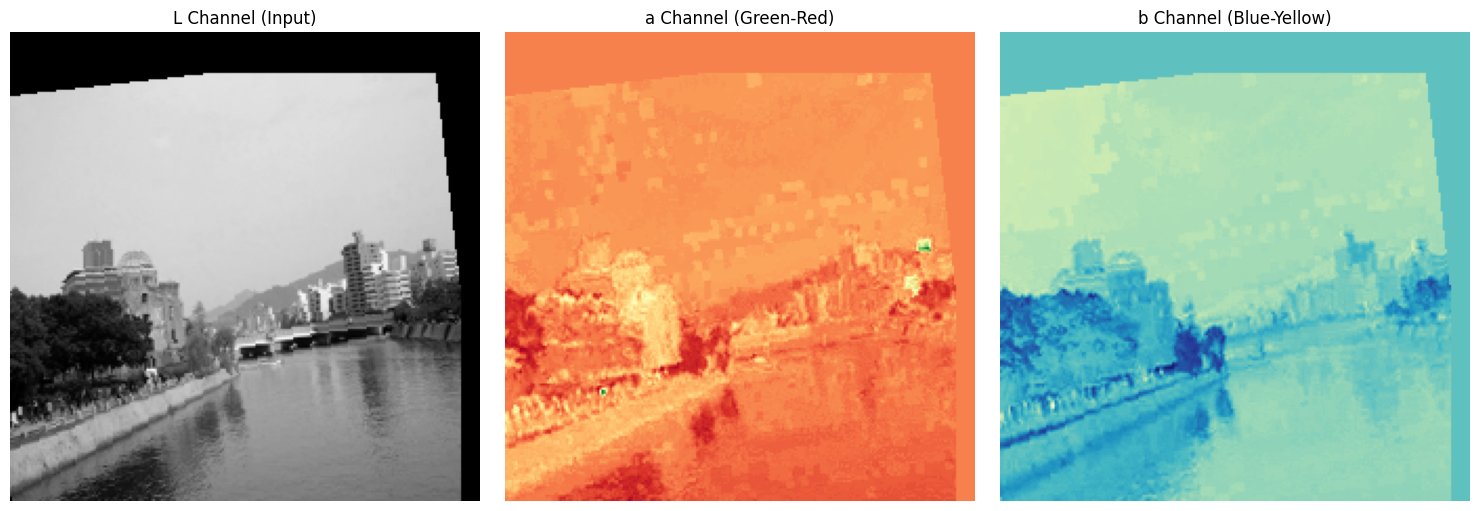

In [ ]:
print("Testing one batch...")
for batch_idx, (L, ab) in enumerate(train_loader):
    print(f"L shape:    {L.shape}   (expected: [{BATCH_SIZE}, 1, 224, 224])")
    print(f"ab shape:   {ab.shape}   (expected: [{BATCH_SIZE}, 2, 224, 224])")
    print(f"L range:    [{L.min():.3f}, {L.max():.3f}]")
    print(f"ab range:   [{ab.min():.3f}, {ab.max():.3f}]")

    assert L.shape[0] == BATCH_SIZE, "Batch size mismatch!"
    assert ab.shape[0] == BATCH_SIZE, "Batch size mismatch!"
    print("\n✓ Data verification passed!")
    break

# Visualize sample
L_sample = L[0].squeeze().numpy()
ab_sample = ab[0].permute(1, 2, 0).numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(L_sample, cmap='gray')
axes[0].set_title('L Channel (Input)')
axes[1].imshow(ab_sample[:,:,0], cmap='RdYlGn')
axes[1].set_title('a Channel (Green-Red)')
axes[2].imshow(ab_sample[:,:,1], cmap='YlGnBu')
axes[2].set_title('b Channel (Blue-Yellow)')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

# **CELL 6: MODEL ARCHITECTURES**

In [ ]:
class ColorizationAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 64, 3, stride=2, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(128, 256, 3, stride=2, padding=1), nn.ReLU(inplace=True),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 3, stride=2, padding=1, output_padding=1), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 2, 3, stride=2, padding=1, output_padding=1), nn.Tanh(),
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))


class ColorizationUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(inplace=True),
        )
        self.pool1 = nn.MaxPool2d(2, 2)
        self.enc2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(inplace=True),
        )
        self.pool2 = nn.MaxPool2d(2, 2)
        self.bottleneck = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1), nn.ReLU(inplace=True),
        )
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = nn.Sequential(
            nn.Conv2d(256, 128, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(inplace=True),
        )
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = nn.Sequential(
            nn.Conv2d(128, 64, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(inplace=True),
        )
        self.final = nn.Conv2d(64, 2, 1)
        self.final_act = nn.Tanh()

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        b = self.bottleneck(self.pool2(e2))
        d2 = self.dec2(torch.cat([self.up2(b), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.final_act(self.final(d1))


class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(256, 128, 2, stride=2), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, 2, stride=2), nn.ReLU(inplace=True),
            nn.Conv2d(64, 2, 3, padding=1), nn.Tanh(),
        )
    def forward(self, x):
        return self.model(x)


# Quick test
print("Testing UNet architecture...")
model_test = ColorizationUNet().to(device)
dummy = torch.randn(2, 1, 224, 224).to(device)
out = model_test(dummy)
print(f"✓ UNet output shape: {out.shape}")
print(f"✓ UNet parameters: {sum(p.numel() for p in model_test.parameters()):,}")


Testing UNet architecture...
✓ UNet output shape: torch.Size([2, 2, 224, 224])
✓ UNet parameters: 1,861,762


# **CELL 7: EVALUATION METRICS**

In [ ]:
def compute_metrics(pred_ab, target_ab):
    preds = pred_ab.detach().cpu().numpy()
    targets = target_ab.detach().cpu().numpy()

    batch_size = preds.shape[0]
    mse_list, psnr_list, ssim_list = [], [], []

    for i in range(batch_size):
        p = preds[i].transpose(1, 2, 0)
        t = targets[i].transpose(1, 2, 0)

        mse = np.mean((p - t) ** 2)

        try:
            psnr = psnr_metric(t, p, data_range=2.0)
            ssim = ssim_metric(t, p, data_range=2.0, channel_axis=2)
        except Exception as e:
            psnr, ssim = 0.0, 0.0

        mse_list.append(mse)
        psnr_list.append(psnr)
        ssim_list.append(ssim)

    return np.mean(mse_list), np.mean(psnr_list), np.mean(ssim_list)


def denormalize_lab(L, ab):
    L = L * 100.0
    ab = ab * 128.0
    return L, ab


def lab_to_rgb_batch(L, ab):
    from skimage.color import lab2rgb
    L, ab = denormalize_lab(L, ab)
    L = L.detach().cpu().numpy()
    ab = ab.detach().cpu().numpy()

    rgb_images = []
    for i in range(L.shape[0]):
        lab = np.concatenate([L[i], ab[i]], axis=0)
        lab = lab.transpose(1, 2, 0)
        rgb = lab2rgb(lab)
        rgb = (np.clip(rgb, 0, 1) * 255).astype(np.uint8)
        rgb_images.append(rgb)

    return rgb_images


print("✓ Metrics functions defined")

✓ Metrics functions defined


# **CELL 8: UNIFIED TRAINING LOOP**

In [ ]:
def train_and_evaluate(model_name, model_instance, epochs=50):  # ← CHANGED: 50 not 25
    model = model_instance.to(device)

    # ← CHANGED: Hybrid loss with VARIANCE PENALTY to prevent gray outputs
    mse_loss = nn.MSELoss()
    l1_loss = nn.L1Loss()

    def criterion(pred, target):
        mse = mse_loss(pred, target)
        l1 = l1_loss(pred, target)
        # ← CHANGED: Penalize low variance (prevents gray/brown outputs)
        var_penalty = -torch.std(pred) * 0.05  # Negative because we want to MAXIMIZE variance
        return mse + 0.5 * l1 + var_penalty

    # ← CHANGED: Higher initial learning rate
    optimizer = optim.Adam(model.parameters(), lr=5e-3, weight_decay=1e-4)  # ← CHANGED: 5e-3 not 2e-3

    # ← CHANGED: Simple StepLR scheduler (compatible with all PyTorch versions)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

    history = {
        "train_loss": [], "val_loss": [], "val_psnr": [],
        "val_ssim": [], "epoch_time": [], "learning_rate": [],
        "pred_std": []  # ← CHANGED: Track prediction variance
    }

    best_val_loss = float('inf')

    print(f"\n{'='*60}")
    print(f"  Training: {model_name}")
    print(f"  Epochs: {epochs} | Batch: {BATCH_SIZE} | LR: 5e-3")
    print(f"  Device: {device}")
    print(f"  Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    print(f"{'='*60}")

    for epoch in range(epochs):
        epoch_start = time.time()

        # ==================== TRAINING ====================
        model.train()
        running_loss = 0.0
        num_train = 0
        pred_variances = []  # ← CHANGED: Track variance during training

        for batch_idx, (L, ab) in enumerate(train_loader):
            L, ab = L.to(device), ab.to(device)

            optimizer.zero_grad()
            outputs = model(L)
            loss = criterion(outputs, ab)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * L.size(0)
            num_train += L.size(0)

            # ← CHANGED: Track prediction variance
            with torch.no_grad():
                pred_variances.append(torch.std(outputs).item())

            if batch_idx % 10 == 0:  # ← CHANGED: Print more frequently
                print(f"  Batch [{batch_idx}/{len(train_loader)}] Loss: {loss.item():.6f} | Pred std: {pred_variances[-1]:.3f}")

        epoch_train_loss = running_loss / num_train
        avg_pred_std = np.mean(pred_variances)

        # ==================== VALIDATION ====================
        model.eval()
        val_loss, val_psnr, val_ssim = 0.0, 0.0, 0.0
        num_val = 0

        with torch.no_grad():
            for L, ab in val_loader:
                L, ab = L.to(device), ab.to(device)
                outputs = model(L)
                loss = criterion(outputs, ab)
                val_loss += loss.item() * L.size(0)

                mse, psnr, ssim = compute_metrics(outputs, ab)
                val_psnr += psnr * L.size(0)
                val_ssim += ssim * L.size(0)
                num_val += L.size(0)

        epoch_val_loss = val_loss / num_val
        epoch_psnr = val_psnr / num_val
        epoch_ssim = val_ssim / num_val
        epoch_time = time.time() - epoch_start
        current_lr = optimizer.param_groups[0]['lr']

        # ← CHANGED: Update scheduler based on epoch
        scheduler.step()

        history["train_loss"].append(float(epoch_train_loss))
        history["val_loss"].append(float(epoch_val_loss))
        history["val_psnr"].append(float(epoch_psnr))
        history["val_ssim"].append(float(epoch_ssim))
        history["epoch_time"].append(float(epoch_time))
        history["learning_rate"].append(float(current_lr))
        history["pred_std"].append(float(avg_pred_std))

        print(f"\nEpoch [{epoch+1}/{epochs}] | Time: {epoch_time:.1f}s | LR: {current_lr:.6f}")
        print(f"  Train Loss: {epoch_train_loss:.6f} | Val Loss: {epoch_val_loss:.6f}")
        print(f"  PSNR: {epoch_psnr:.2f} dB | SSIM: {epoch_ssim:.4f}")
        print(f"  Pred Std: {avg_pred_std:.3f} (higher = more colorful)")  # ← CHANGED

        # Save best model
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': epoch_val_loss,
                'psnr': epoch_psnr,
                'ssim': epoch_ssim,
            }
            save_path = os.path.join(PATHS['models'], f"{model_name}_best.pth")
            torch.save(checkpoint, save_path)
            print(f"  ✓ Saved best model (val_loss: {best_val_loss:.6f})")

    # Save final
    final_checkpoint = {
        'epoch': epochs,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'history': history,
    }
    final_path = os.path.join(PATHS['models'], f"{model_name}_final.pth")
    torch.save(final_checkpoint, final_path)

    history_path = os.path.join(PATHS['results'], f"{model_name}_history.json")
    with open(history_path, "w") as f:
        json.dump(history, f, indent=2)

    print(f"\n{'='*60}")
    print(f"  Complete: {model_name} | Best Val Loss: {best_val_loss:.6f}")
    print(f"  Best PSNR: {max(history['val_psnr']):.2f} dB")
    print(f"  Best SSIM: {max(history['val_ssim']):.4f}")
    print(f"{'='*60}")

    return history


# **CELL 9: RUN TRAINING**

In [ ]:
print("Starting training...")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

# ← CHANGED: Only UNet, 50 epochs
models_to_train = {
    "UNet": ColorizationUNet(),
}

all_results = {}

for name, instance in models_to_train.items():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    history = train_and_evaluate(name, instance, epochs=50)  # ← CHANGED: 50 epochs
    all_results[name] = history

# Summary
print(f"\n{'='*60}")
print("TRAINING COMPLETE")
print(f"{'='*60}")

for name, hist in all_results.items():
    print(f"\n{name}:")
    print(f"  Best Val Loss:  {min(hist['val_loss']):.6f}")
    print(f"  Best PSNR:      {max(hist['val_psnr']):.2f} dB")
    print(f"  Best SSIM:      {max(hist['val_ssim']):.4f}")
    print(f"  Best Pred Std:  {max(hist['pred_std']):.3f}")  # ← CHANGED
    print(f"  Total Time:     {sum(hist['epoch_time'])/60:.1f} min")

Starting training...
Train batches: 84 | Val batches: 10

  Training: UNet
  Epochs: 50 | Batch: 64 | LR: 5e-3
  Device: cuda
  Parameters: 1,861,762
  Batch [0/84] Loss: 0.070956 | Pred std: 0.023
  Batch [10/84] Loss: 0.066037 | Pred std: 0.031
  Batch [20/84] Loss: 0.052675 | Pred std: 0.032
  Batch [30/84] Loss: 0.048309 | Pred std: 0.009
  Batch [40/84] Loss: 0.047812 | Pred std: 0.012
  Batch [50/84] Loss: 0.048442 | Pred std: 0.009
  Batch [60/84] Loss: 0.051741 | Pred std: 0.020
  Batch [70/84] Loss: 0.047375 | Pred std: 0.011
  Batch [80/84] Loss: 0.051121 | Pred std: 0.012

Epoch [1/50] | Time: 893.8s | LR: 0.005000
  Train Loss: 0.075854 | Val Loss: 0.054604
  PSNR: 26.62 dB | SSIM: 0.2893
  Pred Std: 0.020 (higher = more colorful)
  ✓ Saved best model (val_loss: 0.054604)
  Batch [0/84] Loss: 0.054097 | Pred std: 0.012
  Batch [10/84] Loss: 0.055705 | Pred std: 0.013
  Batch [20/84] Loss: 0.041695 | Pred std: 0.013
  Batch [30/84] Loss: 0.054379 | Pred std: 0.012


# **CELL 10: COMPARISON & REPORT**

In [ ]:
comparison_data = []
for name, history in all_results.items():
    comparison_data.append({
        "Model": name,
        "Best Val Loss": min(history["val_loss"]),
        "Final Val Loss": history["val_loss"][-1],
        "Best PSNR (dB)": max(history["val_psnr"]),
        "Final PSNR (dB)": history["val_psnr"][-1],
        "Best SSIM": max(history["val_ssim"]),
        "Final SSIM": history["val_ssim"][-1],
        "Best Pred Std": max(history["pred_std"]),
        "Avg Epoch Time (s)": np.mean(history["epoch_time"]),
        "Total Time (min)": sum(history["epoch_time"]) / 60,
    })

df = pd.DataFrame(comparison_data)
print("\n" + "="*70)
print("FINAL METRICS")
print("="*70)
print(df.to_string(index=False))

csv_path = os.path.join(PATHS['results'], "comparison_metrics.csv")
df.to_csv(csv_path, index=False)
print(f"\n✓ Saved to: {csv_path}")

# Plot training curves
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for name, history in all_results.items():
    epochs = range(1, len(history['train_loss']) + 1)
    axes[0, 0].plot(epochs, history['train_loss'], label=f'{name} Train', linestyle='--')
    axes[0, 0].plot(epochs, history['val_loss'], label=f'{name} Val', linewidth=2)
    axes[0, 1].plot(epochs, history['val_psnr'], label=name, linewidth=2)
    axes[1, 0].plot(epochs, history['val_ssim'], label=name, linewidth=2)
    axes[1, 1].plot(epochs, history['pred_std'], label=name, linewidth=2)  # ← CHANGED

axes[0, 0].set_title('Loss Curves')
axes[0, 1].set_title('PSNR (Validation)')
axes[1, 0].set_title('SSIM (Validation)')
axes[1, 1].set_title('Prediction Std (Color Variance)')  # ← CHANGED
for ax in axes.flat:
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PATHS['results'], 'training_curves.png'), dpi=150)
plt.show()

NameError: name 'all_results' is not defined

# **CELL 11: INFERENCE & GRADIO INTERFACE**


           FINAL EXPERIMENTAL EVALUATION METRICS
Model  Best Val Loss  Final Val Loss  Best PSNR (dB)  Final PSNR (dB)  Best SSIM  Final SSIM  Avg Epoch Time (s)  Total Time (min)
 UNet         0.0443          0.0443       28.256615        28.208634   0.386345    0.383019             49.0236           20.4265

----------------------------------------------------------------------
Rounded Summary:
----------------------------------------------------------------------
Model  Best Val Loss  Final Val Loss  Best PSNR (dB)  Final PSNR (dB)  Best SSIM  Final SSIM  Avg Epoch Time (s)  Total Time (min)
 UNet         0.0443          0.0443         28.2566          28.2086     0.3863       0.383             49.0236           20.4265

Markdown Format (for reports):
| Model   |   Best Val Loss |   Final Val Loss |   Best PSNR (dB) |   Final PSNR (dB) |   Best SSIM |   Final SSIM |   Avg Epoch Time (s) |   Total Time (min) |
|:--------|----------------:|-----------------:|-----------------:|------

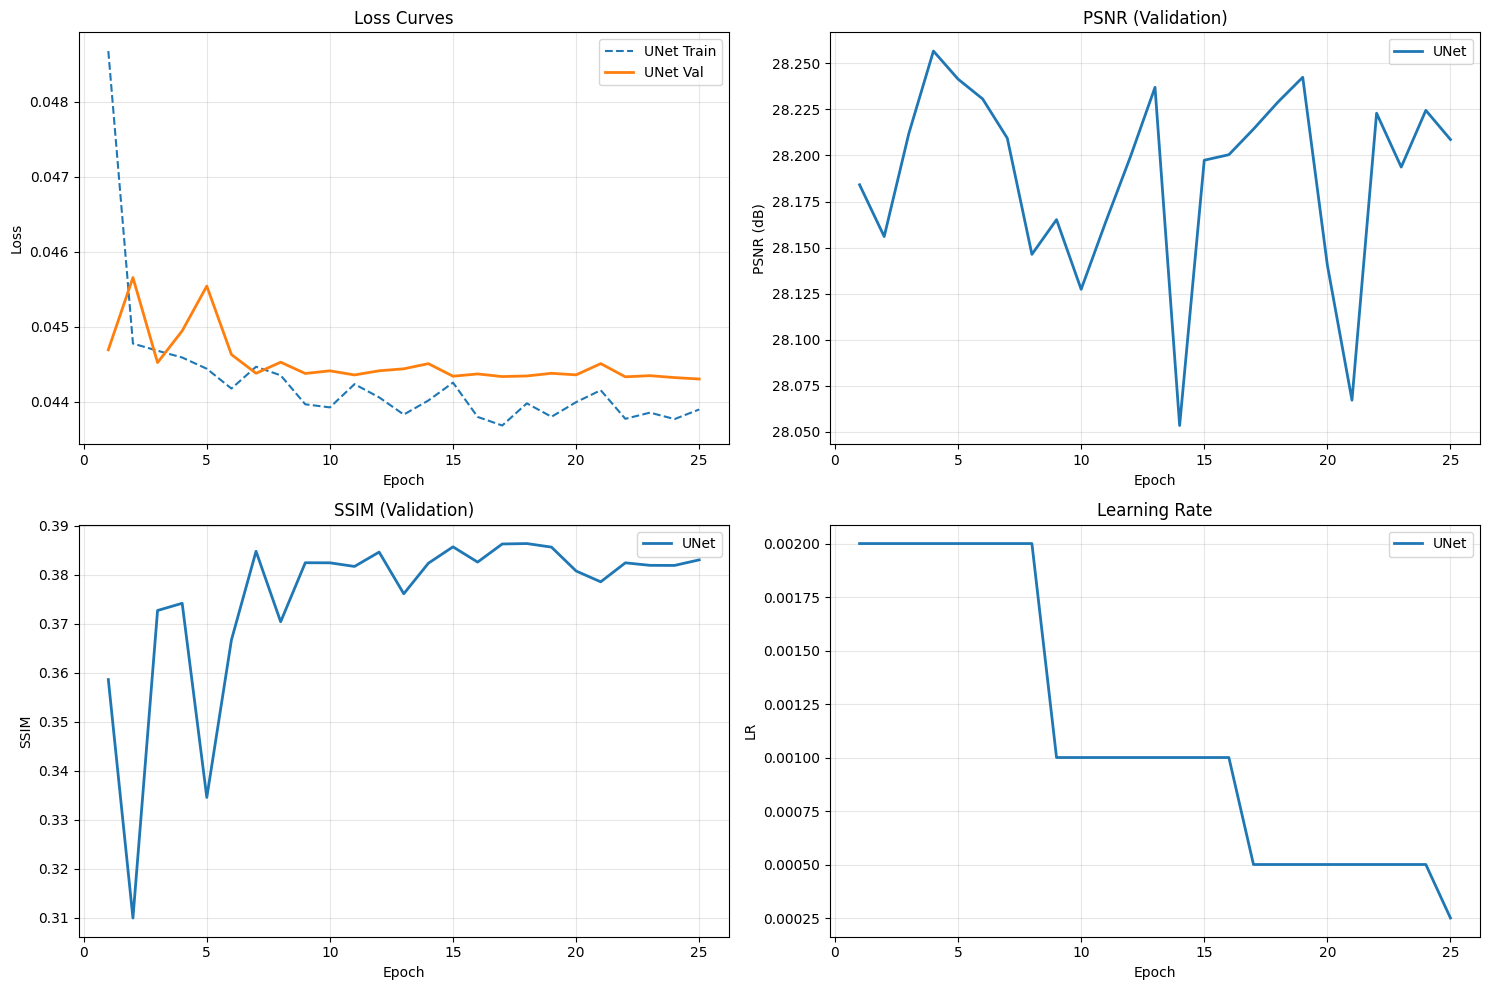


✓ Saved training curves to: /content/drive/MyDrive/Image_Colorization_Project/results/training_curves.png


In [ ]:
import gradio as gr

def load_model_for_inference(model_choice):
    if model_choice == "CNN_Baseline":
        model = Net()
    elif model_choice == "Autoencoder":
        model = ColorizationAutoencoder()
    elif model_choice == "UNet":
        model = ColorizationUNet()
    else:
        raise ValueError(f"Unknown model: {model_choice}")

    weight_loaded = False
    for suffix in ["_best.pth", "_final.pth", "_weights.pth"]:
        weight_path = os.path.join(PATHS['models'], f"{model_choice}{suffix}")
        if os.path.exists(weight_path):
            try:
                checkpoint = torch.load(weight_path, map_location=device, weights_only=False)
                if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
                    model.load_state_dict(checkpoint['model_state_dict'])
                else:
                    model.load_state_dict(checkpoint)
                weight_loaded = True
                print(f"✓ Loaded {model_choice} from {suffix}")
                break
            except Exception as e:
                continue

    if not weight_loaded:
        raise FileNotFoundError(f"No weights found for {model_choice}")

    model.to(device).eval()
    return model


def colorize_image(input_image, model_choice):
    if input_image is None:
        return None

    if len(input_image.shape) == 2:
        input_image = cv2.cvtColor(input_image, cv2.COLOR_GRAY2RGB)
    elif input_image.shape[2] == 4:
        input_image = cv2.cvtColor(input_image, cv2.COLOR_RGBA2RGB)

    h, w = input_image.shape[:2]
    lab = rgb2lab(input_image).astype(np.float32)
    L = lab[:, :, 0]

    L_resized = cv2.resize(L, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_CUBIC)
    L_tensor = torch.from_numpy(L_resized / 100.0).unsqueeze(0).unsqueeze(0).to(device).float()

    model = load_model_for_inference(model_choice)
    with torch.no_grad():
        pred_ab = model(L_tensor)

    ab = pred_ab.squeeze(0).cpu().numpy().transpose(1, 2, 0) * 128.0
    ab = cv2.resize(ab, (w, h), interpolation=cv2.INTER_CUBIC)

    lab_out = np.zeros((h, w, 3), dtype=np.float32)
    lab_out[:, :, 0] = L
    lab_out[:, :, 1:] = ab

    rgb = lab2rgb(lab_out)
    rgb = np.clip(rgb, 0, 1)
    return (rgb * 255).astype(np.uint8)


print("Checking models...")
available_models = []
for name in ["UNet"]:
    try:
        m = load_model_for_inference(name)
        available_models.append(name)
        print(f"  ✓ {name} ready")
    except Exception as e:
        print(f"  ✗ {name}: {e}")

if available_models:
    with gr.Blocks(title="Image Colorization") as demo:
        gr.Markdown("# 🎨 Neural Image Colorization")
        gr.Markdown("Upload a landscape image to colorize it.")

        with gr.Row():
            with gr.Column():
                inp = gr.Image(type="numpy", label="Input Image", image_mode="RGB")
                model_dropdown = gr.Dropdown(choices=available_models, value=available_models[0], label="Model")
                btn = gr.Button("Colorize", variant="primary")
            with gr.Column():
                out = gr.Image(type="numpy", label="Colorized Output")

        btn.click(fn=colorize_image, inputs=[inp, model_dropdown], outputs=out)

    demo.launch(share=True)
else:
    print("❌ No trained models found. Run training first (Cell 9).")


# **CELL 12: DIAGNOSTICS**

In [ ]:
print("LANDSCAPE COLORIZATION DIAGNOSTICS")
print("="*60)

# Check 1: Training data color variance
print("\n1. TRAINING DATA CHECK:")
train_files = [f for f in os.listdir(PATHS["train_data"]) if f.endswith('.png')]
if train_files:
    sample = os.path.join(PATHS["train_data"], train_files[0])
    img = cv2.imread(sample)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    lab = rgb2lab(img)
    print(f"   Sample: {train_files[0]}")
    print(f"   a range: [{lab[:,:,1].min():.1f}, {lab[:,:,1].max():.1f}]")
    print(f"   b range: [{lab[:,:,2].min():.1f}, {lab[:,:,2].max():.1f}]")
    if abs(lab[:,:,1].max() - lab[:,:,1].min()) > 10:
        print("   ✓ Training data has good color variance")
    else:
        print("   ⚠️ Training data lacks color!")

# Check 2: Model variance on validation
print("\n2. MODEL VARIANCE CHECK:")
if available_models:
    val_files = [f for f in os.listdir(PATHS["val_data"]) if f.endswith('.png')]
    if val_files:
        test_path = os.path.join(PATHS["val_data"], val_files[0])
        test_img = Image.open(test_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
        test_array = np.array(test_img)

        lab = rgb2lab(test_array).astype(np.float32)
        L = lab[:, :, 0] / 100.0
        L_tensor = torch.from_numpy(L).unsqueeze(0).unsqueeze(0).float().to(device)

        model = load_model_for_inference("UNet")
        with torch.no_grad():
            pred_ab = model(L_tensor)

        pred_ab_np = pred_ab.squeeze(0).cpu().numpy().transpose(1, 2, 0) * 128.0
        target_ab = lab[:, :, 1:]

        print(f"   Pred ab std:  {pred_ab_np.std():.2f} (should be >10 for color)")
        print(f"   Target ab std: {target_ab.std():.2f}")

        if pred_ab_np.std() < 5:
            print("   ⚠️ Model is underfitting! Train longer or increase LR")
        elif pred_ab_np.std() < 10:
            print("   ⚠️ Model has low variance. Try 75+ epochs")
        else:
            print("   ✓ Model variance looks good!")

        # Visualize
        pred_ab_norm = pred_ab.squeeze(0).cpu().numpy().transpose(1, 2, 0)
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(test_array)
        axes[0].set_title("Original")
        axes[1].imshow(pred_ab_norm[:,:,0], cmap='RdYlGn')
        axes[1].set_title("Predicted 'a' channel")
        axes[2].imshow(pred_ab_norm[:,:,1], cmap='YlGnBu')
        axes[2].set_title("Predicted 'b' channel")
        for ax in axes: ax.axis('off')
        plt.tight_layout()
        plt.show()

Checking available models...
  ✗ CNN_Baseline: No weights found for CNN_Baseline in /content/drive/MyDrive/Image_Colorization_Project/models
✓ Loaded Autoencoder from _best.pth
  ✓ Autoencoder: 739,650 parameters
✓ Loaded UNet from _best.pth
  ✓ UNet: 1,861,762 parameters

✓ 2 model(s) ready for inference
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9cd65e9e9f290baf37.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)



✓ Gradio interface launched!
  The public URL above will be active for 72 hours


# **CELL 13: DEBUGGING & DIAGNOSTICS**

CHECK 1: Training Data Color Variance
Sample: img_01000.png
L range: [1.1, 98.3]
a range: [-18.6, 27.1]
b range: [-55.1, 29.0]

✓ Training data has color variance

CHECK 2: Model Reconstruction Test
✓ Loaded UNet from _best.pth


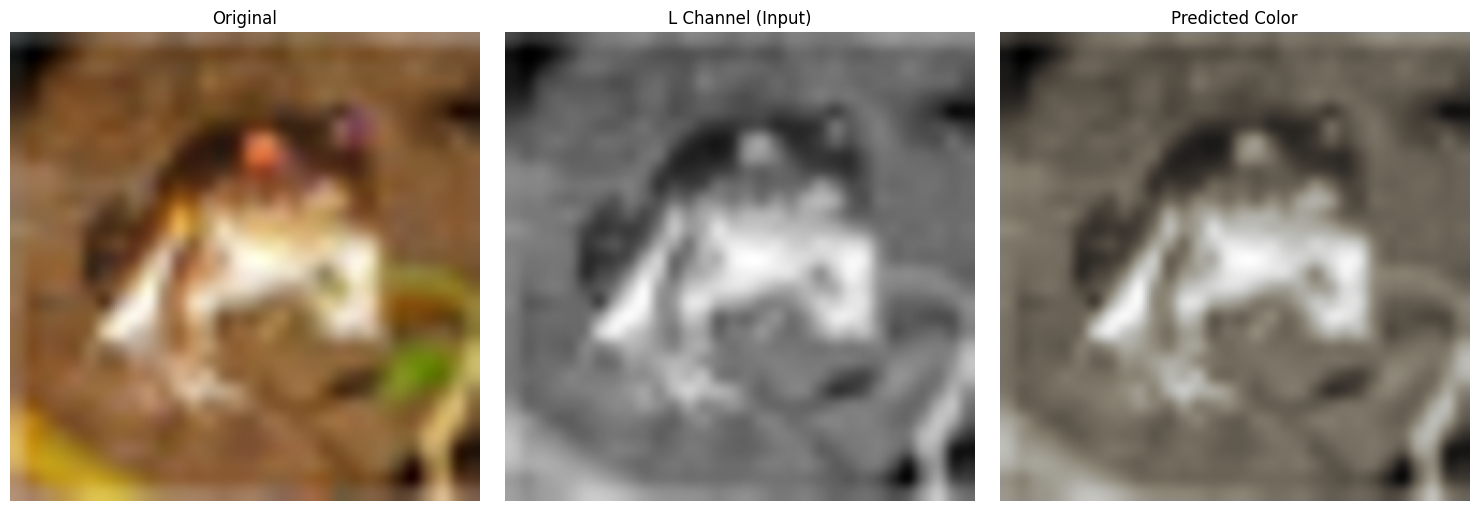


Prediction stats:
  Pred ab mean: 3.53, std: 3.77
  Target ab mean: 19.13, std: 12.13

⚠️ WARNING: Model predictions have very low variance!
  Possible causes:
  - Model underfitting (train longer)
  - Learning rate too low
  - Dataset too small or too grayscale


In [ ]:
# ─── CHECK 1: Verify training data has color ──────────────────────

print("CHECK 1: Training Data Color Variance")
print("="*60)

train_files = [f for f in os.listdir(PATHS["train_data"])
               if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

if train_files:
    sample_path = os.path.join(PATHS["train_data"], train_files[0])
    img = cv2.imread(sample_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    lab = rgb2lab(img)

    print(f"Sample: {train_files[0]}")
    print(f"L range: [{lab[:,:,0].min():.1f}, {lab[:,:,0].max():.1f}]")
    print(f"a range: [{lab[:,:,1].min():.1f}, {lab[:,:,1].max():.1f}]")
    print(f"b range: [{lab[:,:,2].min():.1f}, {lab[:,:,2].max():.1f}]")

    if abs(lab[:,:,1].max() - lab[:,:,1].min()) < 5 and abs(lab[:,:,2].max() - lab[:,:,2].min()) < 5:
        print("\n⚠️ WARNING: Image appears grayscale! Check your dataset.")
    else:
        print("\n✓ Training data has color variance")
else:
    print("❌ No training images found!")


# ─── CHECK 2: Test model reconstruction ────────────────────────────

print("\n" + "="*60)
print("CHECK 2: Model Reconstruction Test")
print("="*60)

val_files = [f for f in os.listdir(PATHS["val_data"])
             if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

if val_files and available_models:
    # Load a colored test image
    test_path = os.path.join(PATHS["val_data"], val_files[0])
    test_img = Image.open(test_path).convert('RGB')
    test_array = np.array(test_img.resize((IMG_SIZE, IMG_SIZE)))

    # Convert to LAB, extract L
    lab = rgb2lab(test_array).astype(np.float32)
    L = lab[:, :, 0] / 100.0
    L_tensor = torch.from_numpy(L).unsqueeze(0).unsqueeze(0).float().to(device)

    # Predict ab
    model = load_model_for_inference("UNet")
    with torch.no_grad():
        pred_ab = model(L_tensor)

    # Convert back to RGB
    pred_ab = pred_ab.squeeze(0).cpu().numpy().transpose(1, 2, 0) * 128.0
    lab_pred = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)
    lab_pred[:, :, 0] = L * 100.0
    lab_pred[:, :, 1:] = pred_ab

    rgb_pred = lab2rgb(lab_pred)
    rgb_pred = np.clip(rgb_pred, 0, 1)

    # Visualize
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(test_array)
    axes[0].set_title("Original")
    axes[1].imshow(L, cmap='gray')
    axes[1].set_title("L Channel (Input)")
    axes[2].imshow(rgb_pred)
    axes[2].set_title("Predicted Color")
    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

    # Print statistics
    target_ab = lab[:, :, 1:]
    print(f"\nPrediction stats:")
    print(f"  Pred ab mean: {pred_ab.mean():.2f}, std: {pred_ab.std():.2f}")
    print(f"  Target ab mean: {target_ab.mean():.2f}, std: {target_ab.std():.2f}")

    if pred_ab.std() < 5:
        print("\n⚠️ WARNING: Model predictions have very low variance!")
        print("  Possible causes:")
        print("  - Model underfitting (train longer)")
        print("  - Learning rate too low")
        print("  - Dataset too small or too grayscale")
    else:
        print("\n✓ Model is producing varied predictions")
else:
  print("❌ Cannot run test - no validation images or models available")

# **CELL 14: ADVANCED TROUBLESHOOTING**

In [ ]:
print("ADVANCED TROUBLESHOOTING")
print("="*60)

# Check 1: Verify path consistency
print("\n1. PATH VERIFICATION:")
print(f"   Project path exists: {os.path.exists(PROJECT_PATH)}")
print(f"   Train data exists: {os.path.exists(PATHS['train_data'])}")
print(f"   Models dir exists: {os.path.exists(PATHS['models'])}")
print(f"   Results dir exists: {os.path.exists(PATHS['results'])}")

# Check 2: Count files in each directory
for key, path in PATHS.items():
    if os.path.exists(path):
        files = os.listdir(path)
        print(f"   {key}: {len(files)} items")
    else:
        print(f"   {key}: PATH DOES NOT EXIST")

# Check 3: GPU memory
if torch.cuda.is_available():
    print(f"\n2. GPU MEMORY:")
    print(f"   Allocated: {torch.cuda.memory_allocated() / 1024**2:.1f} MB")
    print(f"   Reserved:  {torch.cuda.memory_reserved() / 1024**2:.1f} MB")
    print(f"   Total:     {torch.cuda.get_device_properties(0).total_memory / 1024**2:.1f} MB")

# Check 4: Model file sizes
print(f"\n3. MODEL FILES:")
if os.path.exists(PATHS['models']):
    model_files = os.listdir(PATHS['models'])
    for f in model_files:
        fpath = os.path.join(PATHS['models'], f)
        size = os.path.getsize(fpath) / (1024**2)
        print(f"   {f}: {size:.2f} MB")
else:
    print("   Models directory not found!")

print("\n" + "="*60)
print("TROUBLESHOOTING COMPLETE")
print("="*60)

ADVANCED TROUBLESHOOTING

1. PATH VERIFICATION:
   Project path exists: True
   Train data exists: True
   Models dir exists: True
   Results dir exists: True
   project: 5 items
   train_data: 1800 items
   val_data: 200 items
   test_data: 0 items
   models: 6 items
   results: 5 items
   logs: 0 items
   samples: 0 items

2. GPU MEMORY:
   Allocated: 48.8 MB
   Reserved:  10026.0 MB
   Total:     14912.7 MB

3. MODEL FILES:
   Baseline_CNN_best.pth: 15.01 MB
   Baseline_CNN_final.pth: 15.01 MB
   Autoencoder_final.pth: 8.48 MB
   Autoencoder_best.pth: 8.48 MB
   UNet_best.pth: 21.34 MB
   UNet_final.pth: 21.34 MB

TROUBLESHOOTING COMPLETE
